## Deep learning models like Transformer Arima LSTM

In [55]:
print("test")

test


In [56]:
from pathlib import Path
import sys

# Ensure the project src/ directory is importable from the notebook.
_cwd = Path.cwd().resolve()
PROJECT_ROOT = next(
    p for p in [_cwd, *_cwd.parents] if (p / "src" / "timeseries_forecast").exists()
)
SRC_PATH = PROJECT_ROOT / "src"
if str(SRC_PATH) not in sys.path:
    sys.path.insert(0, str(SRC_PATH))

from timeseries_forecast.data_prep.raw_data import read_raw_metals_data
from timeseries_forecast.data_prep.pipeline import run_data_pipeline
from timeseries_forecast.data_prep.data_merge import merge_all_raw_data
from timeseries_forecast.data_prep.constants import RawMetalsColumn

# from timeseries_forecast.feature import autoregressive_features
# from timeseries_forecast.eval.eval import evaluate, evaluate_predictions
# from timeseries_forecast.feature.custom_features import add_log_ret_features
# from timeseries_forecast.feature import engineer_features
# from timeseries_forecast.config.feature_config import FeatureConfig
from timeseries_forecast.data_prep.data_resample import resample_dataframe_with_aggregations

In [57]:
alu_df = read_raw_metals_data("aluminium")
alu_df.Date

0      2024-08-29
1      2024-08-28
2      2024-08-27
3      2024-08-26
4      2024-08-23
          ...    
2730   2014-01-07
2731   2014-01-06
2732   2014-01-03
2733   2014-01-02
2734   2014-01-01
Name: Date, Length: 2735, dtype: datetime64[us]

## Cleaning for all metals with same parameters

### Aluminium

In [58]:
aluminium_df_cleaned = run_data_pipeline(
    read_raw_metals_data("aluminium"),
    timestamp_column=RawMetalsColumn.OPEN_TIME,
    data_freq="D",
    split_train_end="2019-12-31",
    split_val_end="2021-12-31",
    zero_value_ignore_cols=[RawMetalsColumn.PCT_CHANGE],
    zero_as_nan_cols=[RawMetalsColumn.VOLUME],
).rename(columns={RawMetalsColumn.PRICE: "Close"}).drop(columns=[RawMetalsColumn.PCT_CHANGE])
aluminium_df_cleaned


Duplikat-Check
OK: Keine doppelten Zeitstempel im Index
WARN: 4 Zeilen sind doppelt (identischer Inhalt)
  Beispiele (erste 5 Timestamps):
DatetimeIndex(['2020-09-29', '2020-09-30', '2024-07-30', '2024-07-31'], dtype='datetime64[us]', name='RawMetalsColumn.OPEN_TIME', freq=None)

Fehlende Werte Check
WARN: Es gibt 1159 Lücken in der Zeitreihe (erwartete Frequenz: D).

NaN-Check
WARN: 15 NaN-Werte insgesamt gefunden:
  Vol.: 15 (0.55%)

0-Werte Check
WARN: 32 0-Werte insgesamt gefunden:
  Vol.: 32 (1.17%)

Data Cleaning – Interpolation von Missing Values und Nullwerten

  Vollständiger Zeitindex: 3,894 Einträge
  Aktueller DataFrame:    2,735 Zeilen
  Zu ergänzende Einträge: 1,159
    RawMetalsColumn.VOLUME: 32 Nullwerte -> NaN ersetzt

  Interpoliere 6 numerische Spalten:
    Price: 1159 -> 0 NaN
    Open: 1159 -> 0 NaN
    High: 1159 -> 0 NaN
    Low: 1159 -> 0 NaN
    Vol.: 1206 -> 0 NaN
    Change %: 1159 -> 0 NaN

  Shape vorher:  (2735, 6)
  Shape nachher: (3894, 6)
OK: Interpola

,Close,Open,High,Low,Vol.,Mode
2014-01-01,110.10,110.000000,110.700000,109.900000,450.000000,Train
2014-01-02,111.20,110.550000,112.200000,110.450000,4720.000000,Train
2014-01-03,109.20,110.900000,111.100000,109.050000,4520.000000,Train
2014-01-04,109.35,110.433333,110.650000,108.733333,4333.333333,Train
2014-01-05,109.50,109.966667,110.200000,108.416667,4146.666667,Train
...,...,...,...,...,...,...
2024-08-25,229.60,229.450000,232.433333,227.483333,1236.666667,Test
2024-08-26,229.50,230.850000,233.500000,228.850000,510.000000,Test
2024-08-27,231.55,229.000000,233.000000,228.200000,60.000000,Test
2024-08-28,232.05,233.400000,233.400000,231.400000,35.000000,Test


In [59]:
# alu_df_cleaned.loc["25-08-2024"]

### Copper

In [60]:
copper_df_cleaned = run_data_pipeline(
    read_raw_metals_data("copper"),
    timestamp_column=RawMetalsColumn.OPEN_TIME,
    data_freq="D",
    split_train_end="2019-12-31",
    split_val_end="2021-12-31",
    zero_value_ignore_cols=[RawMetalsColumn.PCT_CHANGE],
    zero_as_nan_cols=[RawMetalsColumn.VOLUME],
).rename(columns={RawMetalsColumn.PRICE: "Close"}).drop(columns=[RawMetalsColumn.PCT_CHANGE])


Duplikat-Check
OK: Keine doppelten Zeitstempel im Index
OK: Keine identischen Zeilenduplikate gefunden

Fehlende Werte Check
WARN: Es gibt 1136 Lücken in der Zeitreihe (erwartete Frequenz: D).

NaN-Check
WARN: 20 NaN-Werte insgesamt gefunden:
  Vol.: 20 (0.73%)

0-Werte Check
WARN: 5 0-Werte insgesamt gefunden:
  Vol.: 5 (0.18%)

Data Cleaning – Interpolation von Missing Values und Nullwerten

  Vollständiger Zeitindex: 3,894 Einträge
  Aktueller DataFrame:    2,758 Zeilen
  Zu ergänzende Einträge: 1,136
    RawMetalsColumn.VOLUME: 5 Nullwerte -> NaN ersetzt

  Interpoliere 6 numerische Spalten:
    Price: 1136 -> 0 NaN
    Open: 1136 -> 0 NaN
    High: 1136 -> 0 NaN
    Low: 1136 -> 0 NaN
    Vol.: 1161 -> 0 NaN
    Change %: 1136 -> 0 NaN

  Shape vorher:  (2758, 6)
  Shape nachher: (3894, 6)
OK: Interpolation abgeschlossen!

Duplikat-Check
OK: Keine doppelten Zeitstempel im Index
OK: Keine identischen Zeilenduplikate gefunden

Fehlende Werte Check
OK: Keine Lücken in der Zeitreihe 

### gold

In [61]:
gold_df_cleaned = run_data_pipeline(
    read_raw_metals_data("gold"),
    timestamp_column=RawMetalsColumn.OPEN_TIME,
    data_freq="D",
    split_train_end="2019-12-31",
    split_val_end="2021-12-31",
    zero_value_ignore_cols=[RawMetalsColumn.PCT_CHANGE],
    zero_as_nan_cols=[RawMetalsColumn.VOLUME],
).rename(columns={RawMetalsColumn.PRICE: "Close"}).drop(columns=[RawMetalsColumn.PCT_CHANGE])


Duplikat-Check
OK: Keine doppelten Zeitstempel im Index
OK: Keine identischen Zeilenduplikate gefunden

Fehlende Werte Check
WARN: Es gibt 1135 Lücken in der Zeitreihe (erwartete Frequenz: D).

NaN-Check
WARN: 22 NaN-Werte insgesamt gefunden:
  Vol.: 22 (0.80%)

0-Werte Check
WARN: 7 0-Werte insgesamt gefunden:
  Vol.: 7 (0.25%)

Data Cleaning – Interpolation von Missing Values und Nullwerten

  Vollständiger Zeitindex: 3,895 Einträge
  Aktueller DataFrame:    2,760 Zeilen
  Zu ergänzende Einträge: 1,135
    RawMetalsColumn.VOLUME: 7 Nullwerte -> NaN ersetzt

  Interpoliere 6 numerische Spalten:
    Price: 1135 -> 0 NaN
    Open: 1135 -> 0 NaN
    High: 1135 -> 0 NaN
    Low: 1135 -> 0 NaN
    Vol.: 1164 -> 0 NaN
    Change %: 1135 -> 0 NaN

  Shape vorher:  (2760, 6)
  Shape nachher: (3895, 6)
OK: Interpolation abgeschlossen!

Duplikat-Check
OK: Keine doppelten Zeitstempel im Index
OK: Keine identischen Zeilenduplikate gefunden

Fehlende Werte Check
OK: Keine Lücken in der Zeitreihe 

### lead

In [62]:
lead_df_cleaned = run_data_pipeline(
    read_raw_metals_data("lead"),
    timestamp_column=RawMetalsColumn.OPEN_TIME,
    data_freq="D",
    split_train_end="2019-12-31",
    split_val_end="2021-12-31",
    zero_value_ignore_cols=[RawMetalsColumn.PCT_CHANGE],
    zero_as_nan_cols=[RawMetalsColumn.VOLUME],
    fail_on_row_duplicates=False,
).rename(columns={RawMetalsColumn.PRICE: "Close"}).drop(columns=[RawMetalsColumn.PCT_CHANGE])


Duplikat-Check
OK: Keine doppelten Zeitstempel im Index
WARN: 6 Zeilen sind doppelt (identischer Inhalt)
  Beispiele (erste 5 Timestamps):
DatetimeIndex(['2023-03-29', '2023-03-30', '2023-07-27', '2023-07-28',
               '2024-02-26'],
              dtype='datetime64[us]', name='RawMetalsColumn.OPEN_TIME', freq=None)

Fehlende Werte Check
WARN: Es gibt 1137 Lücken in der Zeitreihe (erwartete Frequenz: D).

NaN-Check
WARN: 31 NaN-Werte insgesamt gefunden:
  Vol.: 31 (1.12%)

0-Werte Check
WARN: 45 0-Werte insgesamt gefunden:
  Vol.: 45 (1.63%)

Data Cleaning – Interpolation von Missing Values und Nullwerten

  Vollständiger Zeitindex: 3,894 Einträge
  Aktueller DataFrame:    2,757 Zeilen
  Zu ergänzende Einträge: 1,137
    RawMetalsColumn.VOLUME: 45 Nullwerte -> NaN ersetzt

  Interpoliere 6 numerische Spalten:
    Price: 1137 -> 0 NaN
    Open: 1137 -> 0 NaN
    High: 1137 -> 0 NaN
    Low: 1137 -> 0 NaN
    Vol.: 1213 -> 0 NaN
    Change %: 1137 -> 0 NaN

  Shape vorher:  (2757, 

### nickel

In [63]:
nickel_df_cleaned = run_data_pipeline(
    read_raw_metals_data("nickel"),
    timestamp_column=RawMetalsColumn.OPEN_TIME,
    data_freq="D",
    split_train_end="2019-12-31",
    split_val_end="2021-12-31",
    zero_value_ignore_cols=[RawMetalsColumn.PCT_CHANGE],
    zero_as_nan_cols=[
        RawMetalsColumn.VOLUME,
        RawMetalsColumn.OPEN,
        RawMetalsColumn.HIGH,
        RawMetalsColumn.LOW,
    ],
).rename(columns={RawMetalsColumn.PRICE: "Close"}).drop(columns=[RawMetalsColumn.PCT_CHANGE])
nickel_df_cleaned


Duplikat-Check
OK: Keine doppelten Zeitstempel im Index
WARN: 21 Zeilen sind doppelt (identischer Inhalt)
  Beispiele (erste 5 Timestamps):
DatetimeIndex(['2022-05-27', '2022-05-30', '2022-05-31', '2022-06-02',
               '2022-06-03'],
              dtype='datetime64[us]', name='RawMetalsColumn.OPEN_TIME', freq=None)

Fehlende Werte Check
WARN: Es gibt 1139 Lücken in der Zeitreihe (erwartete Frequenz: D).

NaN-Check
WARN: 580 NaN-Werte insgesamt gefunden:
  Vol.: 580 (21.05%)

0-Werte Check
WARN: 40 0-Werte insgesamt gefunden:
  Open: 1 (0.04%)
  High: 1 (0.04%)
  Low: 1 (0.04%)
  Vol.: 37 (1.34%)

Data Cleaning – Interpolation von Missing Values und Nullwerten

  Vollständiger Zeitindex: 3,894 Einträge
  Aktueller DataFrame:    2,755 Zeilen
  Zu ergänzende Einträge: 1,139
    RawMetalsColumn.VOLUME: 37 Nullwerte -> NaN ersetzt
    RawMetalsColumn.OPEN: 1 Nullwerte -> NaN ersetzt
    RawMetalsColumn.HIGH: 1 Nullwerte -> NaN ersetzt
    RawMetalsColumn.LOW: 1 Nullwerte -> NaN erse

,Close,Open,High,Low,Vol.,Mode
2014-01-01,866.100000,867.000000,869.900000,863.000000,2430.000000,Train
2014-01-02,875.200000,869.900000,880.500000,862.600000,20390.000000,Train
2014-01-03,865.100000,873.100000,875.000000,863.500000,13910.000000,Train
2014-01-04,865.100000,865.100000,865.100000,865.100000,16163.333333,Train
2014-01-05,858.100000,866.300000,867.200000,856.100000,18416.666667,Train
...,...,...,...,...,...,...
2024-08-25,1415.833333,1415.833333,1415.833333,1415.833333,20.000000,Test
2024-08-26,1420.400000,1420.400000,1420.400000,1420.400000,20.000000,Test
2024-08-27,1420.400000,1420.400000,1420.400000,1420.400000,20.000000,Test
2024-08-28,1438.000000,1438.000000,1438.000000,1438.000000,20.000000,Test


### silver

In [64]:
silver_df_cleaned = run_data_pipeline(
    read_raw_metals_data("silver"),
    timestamp_column=RawMetalsColumn.OPEN_TIME,
    data_freq="D",
    split_train_end="2019-12-31",
    split_val_end="2021-12-31",
    zero_value_ignore_cols=[RawMetalsColumn.PCT_CHANGE],
    zero_as_nan_cols=[
        RawMetalsColumn.VOLUME,
        RawMetalsColumn.OPEN,
        RawMetalsColumn.HIGH,
        RawMetalsColumn.LOW,
    ],
).rename(columns={RawMetalsColumn.PRICE: "Close"}).drop(columns=[RawMetalsColumn.PCT_CHANGE])


Duplikat-Check
OK: Keine doppelten Zeitstempel im Index
OK: Keine identischen Zeilenduplikate gefunden

Fehlende Werte Check
WARN: Es gibt 1136 Lücken in der Zeitreihe (erwartete Frequenz: D).

NaN-Check
WARN: 18 NaN-Werte insgesamt gefunden:
  Vol.: 18 (0.65%)

0-Werte Check
WARN: 5 0-Werte insgesamt gefunden:
  Vol.: 5 (0.18%)

Data Cleaning – Interpolation von Missing Values und Nullwerten

  Vollständiger Zeitindex: 3,895 Einträge
  Aktueller DataFrame:    2,759 Zeilen
  Zu ergänzende Einträge: 1,136
    RawMetalsColumn.VOLUME: 5 Nullwerte -> NaN ersetzt

  Interpoliere 6 numerische Spalten:
    Price: 1136 -> 0 NaN
    Open: 1136 -> 0 NaN
    High: 1136 -> 0 NaN
    Low: 1136 -> 0 NaN
    Vol.: 1159 -> 0 NaN
    Change %: 1136 -> 0 NaN

  Shape vorher:  (2759, 6)
  Shape nachher: (3895, 6)
OK: Interpolation abgeschlossen!

Duplikat-Check
OK: Keine doppelten Zeitstempel im Index
OK: Keine identischen Zeilenduplikate gefunden

Fehlende Werte Check
OK: Keine Lücken in der Zeitreihe 

### zinc

In [65]:
zinc_df_cleaned = run_data_pipeline(
    read_raw_metals_data("zinc"),
    timestamp_column=RawMetalsColumn.OPEN_TIME,
    data_freq="D",
    split_train_end="2019-12-31",
    split_val_end="2021-12-31",
    zero_value_ignore_cols=[RawMetalsColumn.PCT_CHANGE],
    zero_as_nan_cols=[RawMetalsColumn.VOLUME],
).rename(columns={RawMetalsColumn.PRICE: "Close"}).drop(columns=[RawMetalsColumn.PCT_CHANGE])


Duplikat-Check
OK: Keine doppelten Zeitstempel im Index
OK: Keine identischen Zeilenduplikate gefunden

Fehlende Werte Check
WARN: Es gibt 1137 Lücken in der Zeitreihe (erwartete Frequenz: D).

NaN-Check
WARN: 19 NaN-Werte insgesamt gefunden:
  Vol.: 19 (0.69%)

0-Werte Check
WARN: 13 0-Werte insgesamt gefunden:
  Vol.: 13 (0.47%)

Data Cleaning – Interpolation von Missing Values und Nullwerten

  Vollständiger Zeitindex: 3,895 Einträge
  Aktueller DataFrame:    2,758 Zeilen
  Zu ergänzende Einträge: 1,137
    RawMetalsColumn.VOLUME: 13 Nullwerte -> NaN ersetzt

  Interpoliere 6 numerische Spalten:
    Price: 1137 -> 0 NaN
    Open: 1137 -> 0 NaN
    High: 1137 -> 0 NaN
    Low: 1137 -> 0 NaN
    Vol.: 1169 -> 0 NaN
    Change %: 1137 -> 0 NaN

  Shape vorher:  (2758, 6)
  Shape nachher: (3895, 6)
OK: Interpolation abgeschlossen!

Duplikat-Check
OK: Keine doppelten Zeitstempel im Index
OK: Keine identischen Zeilenduplikate gefunden

Fehlende Werte Check
OK: Keine Lücken in der Zeitrei

## SP 500

In [66]:
sp500_df_cleaned = run_data_pipeline(
    read_raw_metals_data("sp500"),
    timestamp_column=RawMetalsColumn.OPEN_TIME,
    data_freq="D",
    split_train_end="2019-12-31",
    split_val_end="2021-12-31",
    zero_value_ignore_cols=[
        RawMetalsColumn.PCT_CHANGE,
        RawMetalsColumn.VOLUME],
    zero_as_nan_cols=[
        RawMetalsColumn.OPEN,
        RawMetalsColumn.HIGH,
        RawMetalsColumn.LOW,
    ],
).rename(columns={RawMetalsColumn.PRICE: "Close"}).drop(columns=[RawMetalsColumn.PCT_CHANGE]).drop(columns=[RawMetalsColumn.VOLUME])


Duplikat-Check
OK: Keine doppelten Zeitstempel im Index
OK: Keine identischen Zeilenduplikate gefunden

Fehlende Werte Check
WARN: Es gibt 1602 Lücken in der Zeitreihe (erwartete Frequenz: D).

NaN-Check
WARN: 3540 NaN-Werte insgesamt gefunden:
  Vol.: 3540 (99.97%)

0-Werte Check
OK: Keine 0-Werte gefunden!

Data Cleaning – Interpolation von Missing Values und Nullwerten

  Vollständiger Zeitindex: 5,143 Einträge
  Aktueller DataFrame:    3,541 Zeilen
  Zu ergänzende Einträge: 1,602

  Interpoliere 6 numerische Spalten:
    Price: 1602 -> 0 NaN
    Open: 1602 -> 0 NaN
    High: 1602 -> 0 NaN
    Low: 1602 -> 0 NaN
    Vol.: 5142 -> 0 NaN
    Change %: 1602 -> 0 NaN

  Shape vorher:  (3541, 6)
  Shape nachher: (5143, 6)
OK: Interpolation abgeschlossen!

Duplikat-Check
OK: Keine doppelten Zeitstempel im Index
OK: Keine identischen Zeilenduplikate gefunden

Fehlende Werte Check
OK: Keine Lücken in der Zeitreihe gefunden (Frequenz: D).

NaN-Check
OK: Keine NaN-Werte gefunden!

0-Werte Ch

## Merge

In [67]:
merged_df = merge_all_raw_data(
    aluminium_df_cleaned=aluminium_df_cleaned,
    copper_df_cleaned=copper_df_cleaned,
    gold_df_cleaned=gold_df_cleaned,
    lead_df_cleaned=lead_df_cleaned,
    nickel_df_cleaned=nickel_df_cleaned,
    silver_df_cleaned=silver_df_cleaned,
    zinc_df_cleaned=zinc_df_cleaned,
    sp500_df_cleaned=sp500_df_cleaned,
)

In [68]:
df = merged_df.copy()
df.columns

Index(['ALU_Close', 'ALU_Open', 'ALU_High', 'ALU_Low', 'ALU_Vol.', 'ALU_Mode',
       'COPPER_Close', 'COPPER_Open', 'COPPER_High', 'COPPER_Low',
       'COPPER_Vol.', 'COPPER_Mode', 'GOLD_Close', 'GOLD_Open', 'GOLD_High',
       'GOLD_Low', 'GOLD_Vol.', 'GOLD_Mode', 'LEAD_Close', 'LEAD_Open',
       'LEAD_High', 'LEAD_Low', 'LEAD_Vol.', 'LEAD_Mode', 'NICKEL_Close',
       'NICKEL_Open', 'NICKEL_High', 'NICKEL_Low', 'NICKEL_Vol.',
       'NICKEL_Mode', 'SILVER_Close', 'SILVER_Open', 'SILVER_High',
       'SILVER_Low', 'SILVER_Vol.', 'SILVER_Mode', 'ZINC_Close', 'ZINC_Open',
       'ZINC_High', 'ZINC_Low', 'ZINC_Vol.', 'ZINC_Mode', 'SP500_Close',
       'SP500_Open', 'SP500_High', 'SP500_Low', 'SP500_Mode'],
      dtype='str')

In [69]:
# # Test the resample function
frequency_resample = '7D'

resampled = resample_dataframe_with_aggregations(df, frequency_resample)
print(f"Original shape: {df.shape}")
print(f"Resampled {frequency_resample} shape: {resampled.shape}")
print(f"\nFirst few rows of resampled data:")
print(resampled.head())

df = resampled.copy()

Original shape: (3894, 47)
Resampled 7D shape: (557, 47)

First few rows of resampled data:
            ALU_Close  ALU_Open  ALU_High  ALU_Low  ALU_Vol. ALU_Mode  \
2014-01-01     109.30    110.00    112.20   108.10    3110.0    Train   
2014-01-08     106.50    109.35    109.50   106.20    3260.0    Train   
2014-01-15     109.30    106.40    110.35   106.05    5340.0    Train   
2014-01-22     107.70    109.50    109.75   107.05    3120.0    Train   
2014-01-29     104.05    107.20    107.75   103.50    5620.0    Train   

            COPPER_Close  COPPER_Open  COPPER_High  COPPER_Low  ...  \
2014-01-01        465.35       469.25       474.40       462.9  ...   
2014-01-08        455.55       466.00       467.40       453.3  ...   
2014-01-15        461.25       454.90       462.00       452.3  ...   
2014-01-22        453.00       460.55       461.55       451.9  ...   
2014-01-29        441.15       452.15       454.20       440.7  ...   

            ZINC_Open ZINC_High  ZINC_Low 

In [70]:
# models = [
#     # RandomForestRegressor(random_state=42),
#     # DecisionTreeRegressor(random_state=42),
#     SVR(),
#     LinearSVR(random_state=42),
#     LGBMRegressor(random_state=42),
#     XGBRegressor(random_state=42),
#     LinearRegression(),
#     KNeighborsRegressor()
# ]

In [71]:
# fügt eine type spalte als label (target) hinzu
# macht die timestamp spalte explizit, damit man daraus infos extrahieren kann

df["type"] = "Aluminium"
df["timestamp"] = df.index

In [72]:
# add log ret features
from timeseries_forecast.feature.custom_features import add_log_ret_features

feature_df, feature_name_btc_log_ret = add_log_ret_features(df, "ALU_Close")
#feature_df, feature_name_eth_log_ret = add_log_ret_features(feature_df, "ETH_Close")

In [73]:
# feature_df.columns

In [74]:
#without mode

numeric_feature_columns = ['ALU_Close', 'ALU_Open', 'ALU_High', 'ALU_Low',
       'ALU_Vol.', 'COPPER_Close', 'COPPER_Open',
       'COPPER_High', 'COPPER_Low', 'COPPER_Vol.', 'GOLD_Close',
       'GOLD_Open', 'GOLD_High', 'GOLD_Low', 'GOLD_Vol.',
       'LEAD_Close', 'LEAD_Open', 'LEAD_High', 'LEAD_Low', 'LEAD_Vol.',
       'NICKEL_Close', 'NICKEL_Open', 'NICKEL_High', 'NICKEL_Low',
       'NICKEL_Vol.', 'SILVER_Close', 'SILVER_Open',
       'SILVER_High', 'SILVER_Low', 'SILVER_Vol.', 'ZINC_Close',
       'ZINC_Open', 'ZINC_High', 'ZINC_Low', 'ZINC_Vol.', 'SP500_Close',
       'SP500_Open', 'SP500_High', 'SP500_Low'
       ]

# Feature Engineering

### Lag Features

lag features sind die Features, die die Werte von den Vorherigen Zeilen annehemn, hier wird durch lag_window_len festgelegt, wie weit dies in die Zukunft gelegt werden soll. Zb bei einer täglichen Frequency und bei einer lag_window_len = 12, werden für jeden Wert die Werte der letzten 12 Tage gespeichert. 

In [75]:
from timeseries_forecast.feature import engineer_features
lag_window_len = 12

lag = list(range(1, lag_window_len + 1))

features = []
for column in numeric_feature_columns:
    features.append(
        engineer_features.LaggingFeatures
        (
            column=column, 
            lags=lag,
         
        )
    )
    

### Rolling Features

In [76]:
for column in numeric_feature_columns:
    features.append(
        engineer_features.RollingFeatures
        (
            column=column, 
            rolls=[3, 6, 12],
            agg_funcs=["mean", "std", "min", "max"]
        )
    )

### Temporal Features

In [77]:
# features.append(
#     engineer_features.TemporalFeatures
#     (
#         column="timestamp",
#         frequency="24h"
#     )
# )

# print("✓ Temporal features added")

### Fourier Features (Seasonal Patterns)

In [78]:
# # Add Fourier features for capturing seasonal patterns in the data
# # These are useful for recurring patterns like yearly seasonality
# features.append(
#     engineer_features.FourierFeatures
#     (
#         column="timestamp",
#         max_value=365,  # Yearly seasonality (365 daily observations per year)
#         n_fourier_terms=4  # 4 sine and 4 cosine terms
#     )
# )

# print("✓ Fourier features added (yearly seasonality with 4 terms)")

# Feature Definition

In [79]:
from timeseries_forecast.config.feature_config import FeatureConfig 
from timeseries_forecast.data_prep.data_resample import resample_dataframe_with_aggregations
import pandas as pd

def define_features(df: pd.DataFrame, forecast_horizon: int):
    feature_engineer = engineer_features.FeatureEngineeringConfig(features=features)
    features_df, added_features = feature_engineer.create_features(df, forecast_horizon)

    #this line adds contemp eth log return as feature
    #added_features.extend(feature_name_eth_log_ret)

    feat_config = FeatureConfig(
        date="timestamp",
        target="ALU_Close_log_ret",
        continuous_features=added_features,
        categorical_features=[],
        boolean_features=[],
        index_cols=["type","timestamp"],
        exogenous_features=[],
    )

    return feat_config, features_df

In [80]:
#forecast horizon defined here 
feature_config, features_df = define_features(feature_df, forecast_horizon=1)

/data/home/zap43137/Fpp_KI_server/fpp/src/timeseries_forecast/feature/autoregressive_features.py:39: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df = df.assign(**col_dict)
/data/home/zap43137/Fpp_KI_server/fpp/src/timeseries_forecast/feature/autoregressive_features.py:79: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df = df.assign(**rolling_df.to_dict("list"))
/data/home/zap43137/Fpp_KI_server/fpp/src/timeseries_forecast/feature/autoregressive_features.py:79: PerformanceWarning: DataFrame is highly fragmented.  This is usuall

In [81]:
df_train = features_df[features_df["ALU_Mode"] == "Train"].dropna()
df_val = features_df[features_df["ALU_Mode"] == "Val"]
df_test = features_df[features_df["ALU_Mode"] == "Test"]

In [82]:
train_features, train_target, _ = feature_config.get_X_y(df_train)
val_features, val_target, _ = feature_config.get_X_y(df_val)
test_features, test_target, _ = feature_config.get_X_y(df_test)

Hier würde jetzt das Training für die Modelle etc kommen

In [83]:
# zB so würde ein model trainiert und evaluiert werden

#  model.fit(train_features, train_target)
#     val_preds = model.predict(val_features)
#     val_eval_df = val_target.copy()
#     val_eval_df["pred"] = val_preds
#     val_score = evaluate(val_eval_df, target_col="Aluminium_Close_log_ret", y_pred_col="pred", do_calculate_directed_accuracy=True)
#     test_preds = model.predict(test_features)
#     test_eval_df = test_target.copy()
#     test_eval_df["pred"] = test_preds
#     test_score = evaluate(test_eval_df, target_col="Aluminium_Close_log_ret", y_pred_col="pred", do_calculate_directed_accuracy=True)
#     return val_score, test_score

In [84]:
import math
from dataclasses import dataclass
from pathlib import Path
from typing import Dict, Tuple

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from sklearn.preprocessing import StandardScaler
from torch import nn
from torch.utils.data import DataLoader, TensorDataset

from timeseries_forecast.eval.eval import evaluate

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RANDOM_STATE)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

TARGET_COL = "ALU_Close_log_ret"
MODE_COL = "ALU_Mode"
LOOKBACK_WINDOW = 24
BATCH_SIZE = 128
N_EPOCHS = 35
LEARNING_RATE = 1e-3
HIDDEN_SIZE = 64
NUM_LAYERS = 2
D_MODEL = 64
N_HEADS = 4
DROPOUT = 0.1
PATIENCE = 5

RESULTS_DIR = PROJECT_ROOT / "results" / "torch_deep_models_1h" / "aluminium_log_ret"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

if TARGET_COL not in feature_df.columns:
    raise KeyError(f"{TARGET_COL} is missing from feature_df")
if MODE_COL not in features_df.columns:
    raise KeyError(f"{MODE_COL} is missing from features_df")

base_df = feature_df.join(features_df[[MODE_COL]], how="inner").sort_index().dropna(subset=[TARGET_COL, MODE_COL])
numeric_input_columns = [col for col in base_df.select_dtypes(include=[np.number]).columns if col != TARGET_COL]
INPUT_COLUMNS = [TARGET_COL] + numeric_input_columns
COVARIATE_COLUMNS = numeric_input_columns

print(f"Base frame shape: {base_df.shape}")
print(f"Using {len(INPUT_COLUMNS)} input channels: target + {len(COVARIATE_COLUMNS)} covariates")
print(base_df[[TARGET_COL, MODE_COL]].head())


@dataclass
class WindowSplit:
    inputs: torch.Tensor
    targets: torch.Tensor
    timestamps: pd.DatetimeIndex



def build_windows(inputs: np.ndarray, targets: np.ndarray, modes: np.ndarray, timestamps: pd.Index, split_name: str) -> WindowSplit:
    input_windows = []
    target_values = []
    target_timestamps = []

    for end_idx in range(LOOKBACK_WINDOW, len(inputs)):
        if modes[end_idx] != split_name:
            continue
        input_windows.append(inputs[end_idx - LOOKBACK_WINDOW:end_idx])
        target_values.append(targets[end_idx])
        target_timestamps.append(timestamps[end_idx])

    inputs_tensor = torch.tensor(np.asarray(input_windows, dtype=np.float32))
    targets_tensor = torch.tensor(np.asarray(target_values, dtype=np.float32))
    return WindowSplit(inputs=inputs_tensor, targets=targets_tensor, timestamps=pd.DatetimeIndex(target_timestamps))



def prepare_data() -> Tuple[WindowSplit, WindowSplit, WindowSplit, StandardScaler, StandardScaler]:
    target_values = base_df[TARGET_COL].to_numpy(dtype=np.float32)
    covariate_values = base_df[COVARIATE_COLUMNS].to_numpy(dtype=np.float32)
    modes = base_df[MODE_COL].to_numpy()
    timestamps = base_df.index

    target_scaler = StandardScaler()
    target_scaler.fit(target_values[modes == "Train"].reshape(-1, 1))
    scaled_target_values = target_scaler.transform(target_values.reshape(-1, 1)).reshape(-1).astype(np.float32)

    covariate_scaler = StandardScaler()
    covariate_scaler.fit(covariate_values[modes == "Train"])
    scaled_covariate_values = covariate_scaler.transform(covariate_values).astype(np.float32)

    scaled_inputs = np.column_stack([scaled_target_values, scaled_covariate_values]).astype(np.float32)

    train_split = build_windows(scaled_inputs, scaled_target_values, modes, timestamps, "Train")
    val_split = build_windows(scaled_inputs, scaled_target_values, modes, timestamps, "Val")
    test_split = build_windows(scaled_inputs, scaled_target_values, modes, timestamps, "Test")
    return train_split, val_split, test_split, target_scaler, covariate_scaler



def make_loader(split: WindowSplit, shuffle: bool) -> DataLoader:
    dataset = TensorDataset(split.inputs, split.targets)
    return DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=shuffle, drop_last=False)



def inverse_transform(scaler: StandardScaler, values: np.ndarray) -> np.ndarray:
    return scaler.inverse_transform(values.reshape(-1, 1)).reshape(-1)


class LSTMForecaster(nn.Module):
    def __init__(self, input_size: int):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=HIDDEN_SIZE,
            num_layers=NUM_LAYERS,
            batch_first=True,
            dropout=DROPOUT if NUM_LAYERS > 1 else 0.0,
        )
        self.head = nn.Linear(HIDDEN_SIZE, 1)

    def forward(self, inputs: torch.Tensor) -> torch.Tensor:
        outputs, _ = self.lstm(inputs)
        return self.head(outputs[:, -1, :]).squeeze(-1)


class GRUForecaster(nn.Module):
    def __init__(self, input_size: int):
        super().__init__()
        self.gru = nn.GRU(
            input_size=input_size,
            hidden_size=HIDDEN_SIZE,
            num_layers=NUM_LAYERS,
            batch_first=True,
            dropout=DROPOUT if NUM_LAYERS > 1 else 0.0,
        )
        self.head = nn.Linear(HIDDEN_SIZE, 1)

    def forward(self, inputs: torch.Tensor) -> torch.Tensor:
        outputs, _ = self.gru(inputs)
        return self.head(outputs[:, -1, :]).squeeze(-1)


class PositionalEncoding(nn.Module):
    def __init__(self, d_model: int, dropout: float = DROPOUT, max_len: int = 4096):
        super().__init__()
        self.dropout = nn.Dropout(dropout)

        position = torch.arange(max_len, dtype=torch.float32).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2, dtype=torch.float32) * (-math.log(10000.0) / d_model))
        pe = torch.zeros(max_len, d_model)
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        self.register_buffer("pe", pe.unsqueeze(0))

    def forward(self, inputs: torch.Tensor) -> torch.Tensor:
        inputs = inputs + self.pe[:, :inputs.size(1)]
        return self.dropout(inputs)


class TransformerForecaster(nn.Module):
    def __init__(self, input_size: int):
        super().__init__()
        self.input_projection = nn.Linear(input_size, D_MODEL)
        self.positional_encoding = PositionalEncoding(d_model=D_MODEL, dropout=DROPOUT)
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=D_MODEL,
            nhead=N_HEADS,
            dim_feedforward=4 * D_MODEL,
            dropout=DROPOUT,
            batch_first=True,
        )
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=NUM_LAYERS)
        self.head = nn.Linear(D_MODEL, 1)

    def forward(self, inputs: torch.Tensor) -> torch.Tensor:
        hidden = self.input_projection(inputs)
        hidden = self.positional_encoding(hidden)
        encoded = self.encoder(hidden)
        return self.head(encoded[:, -1, :]).squeeze(-1)



def build_model(model_name: str, input_size: int) -> nn.Module:
    if model_name == "LSTM":
        return LSTMForecaster(input_size=input_size)
    if model_name == "GRU":
        return GRUForecaster(input_size=input_size)
    if model_name == "Transformer":
        return TransformerForecaster(input_size=input_size)
    raise ValueError(f"Unknown model_name: {model_name}")



def train_model(model: nn.Module, train_loader: DataLoader, val_loader: DataLoader) -> float:
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)

    best_state = None
    best_val_loss = float("inf")
    patience_counter = 0

    for epoch in range(1, N_EPOCHS + 1):
        model.train()
        train_losses = []
        for batch_inputs, batch_targets in train_loader:
            batch_inputs = batch_inputs.to(device)
            batch_targets = batch_targets.to(device)
            optimizer.zero_grad()
            predictions = model(batch_inputs)
            loss = criterion(predictions, batch_targets)
            loss.backward()
            optimizer.step()
            train_losses.append(loss.item())

        model.eval()
        val_losses = []
        with torch.no_grad():
            for batch_inputs, batch_targets in val_loader:
                batch_inputs = batch_inputs.to(device)
                batch_targets = batch_targets.to(device)
                predictions = model(batch_inputs)
                val_losses.append(criterion(predictions, batch_targets).item())

        train_loss = float(np.mean(train_losses)) if train_losses else float("nan")
        val_loss = float(np.mean(val_losses)) if val_losses else float("nan")
        print(f"Epoch {epoch:02d}/{N_EPOCHS} - train_loss={train_loss:.6f} - val_loss={val_loss:.6f}")

        if val_loss < best_val_loss - 1e-8:
            best_val_loss = val_loss
            best_state = {key: value.detach().cpu().clone() for key, value in model.state_dict().items()}
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= PATIENCE:
                print(f"Early stopping after {epoch} epochs")
                break

    if best_state is not None:
        model.load_state_dict(best_state)
    return best_val_loss



def predict(model: nn.Module, inputs: torch.Tensor) -> np.ndarray:
    model.eval()
    predictions = []
    with torch.no_grad():
        for start in range(0, len(inputs), BATCH_SIZE):
            batch_inputs = inputs[start:start + BATCH_SIZE].to(device)
            batch_predictions = model(batch_inputs).cpu().numpy()
            predictions.append(batch_predictions)
    return np.concatenate(predictions, axis=0)



def evaluate_split(model: nn.Module, split: WindowSplit, scaler: StandardScaler, model_name: str):
    scaled_predictions = predict(model, split.inputs)
    raw_predictions = inverse_transform(scaler, scaled_predictions)
    raw_targets = inverse_transform(scaler, split.targets.cpu().numpy())

    eval_df = pd.DataFrame({"target": raw_targets, "pred": raw_predictions}, index=split.timestamps)
    score = evaluate(eval_df, target_col="target", y_pred_col="pred", do_calculate_directed_accuracy=True)

    metrics = {
        "Model": model_name,
        "MAE": score.mae,
        "RMSE": score.rmse,
        "R2": score.r2,
        "Directed_Accuracy": score.directed_accuracy,
    }
    predictions = pd.DataFrame({
        "timestamp": split.timestamps,
        "model": model_name,
        "y_true": raw_targets,
        "y_pred": raw_predictions,
    })
    return metrics, predictions


train_split, val_split, test_split, target_scaler, covariate_scaler = prepare_data()
print(f"Train windows: {len(train_split.inputs)}")
print(f"Val windows: {len(val_split.inputs)}")
print(f"Test windows: {len(test_split.inputs)}")
print(f"Input feature dimension: {train_split.inputs.shape[-1]}")

train_loader = make_loader(train_split, shuffle=True)
val_loader = make_loader(val_split, shuffle=False)

all_metrics = []
all_predictions = []
trained_models = {}
input_size = train_split.inputs.shape[-1]

for model_name in ["Transformer", "LSTM", "GRU"]:
    print("\n" + "=" * 90)
    print(f"Training {model_name}")
    print("=" * 90)
    model = build_model(model_name, input_size=input_size).to(device)
    best_val_loss = train_model(model, train_loader, val_loader)

    val_metrics, _ = evaluate_split(model, val_split, target_scaler, model_name)
    test_metrics, test_predictions = evaluate_split(model, test_split, target_scaler, model_name)

    trained_models[model_name] = model.cpu()

    all_metrics.append({
        "Model": model_name,
        "Best_Val_Loss": best_val_loss,
        "Val_MAE": val_metrics["MAE"],
        "Val_RMSE": val_metrics["RMSE"],
        "Val_R2": val_metrics["R2"],
        "Val_Directed_Accuracy": val_metrics["Directed_Accuracy"],
        "Test_MAE": test_metrics["MAE"],
        "Test_RMSE": test_metrics["RMSE"],
        "Test_R2": test_metrics["R2"],
        "Test_Directed_Accuracy": test_metrics["Directed_Accuracy"],
    })
    all_predictions.append(test_predictions)

results_df = pd.DataFrame(all_metrics).sort_values(["Val_RMSE", "Test_RMSE"]).reset_index(drop=True)
predictions_df = pd.concat(all_predictions, ignore_index=True)

display(results_df)

metrics_path = RESULTS_DIR / "dl_models_metrics.csv"
preds_path = RESULTS_DIR / "dl_models_test_predictions.csv"
results_df.to_csv(metrics_path, index=False)
predictions_df.to_csv(preds_path, index=False)
print(f"Saved metrics to: {metrics_path}")
print(f"Saved predictions to: {preds_path}")

plt.figure(figsize=(14, 5))
truth_df = predictions_df[predictions_df["model"] == results_df.iloc[0]["Model"]].sort_values("timestamp")
plt.plot(truth_df["timestamp"], truth_df["y_true"], label="Ground Truth", color="black", linewidth=1.8)
for model_name in results_df["Model"]:
    model_df = predictions_df[predictions_df["model"] == model_name].sort_values("timestamp")
    plt.plot(model_df["timestamp"], model_df["y_pred"], label=f"Pred {model_name}", alpha=0.85)
plt.title("Deep Learning Models - Aluminium Log Return Predictions")
plt.xlabel("Timestamp")
plt.ylabel(TARGET_COL)
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plot_path = RESULTS_DIR / "dl_models_test_predictions.png"
plt.savefig(plot_path, dpi=150, bbox_inches="tight")
print(f"Saved plot to: {plot_path}")
plt.show()


Using device: cpu


ValueError: columns overlap but no suffix specified: Index(['ALU_Mode'], dtype='str')

,timestamp,model,y_true,y_pred,actual_close,prev_close,true_close_from_returns,pred_close
0,2021-12-29,Transformer,-0.004632,0.005213,226.15,227.20,226.150007,228.387405
1,2022-01-05,Transformer,0.034763,0.004666,234.15,226.15,234.150002,227.207582
2,2022-01-12,Transformer,0.020083,0.004173,238.90,234.15,238.900014,235.129267
3,2022-01-19,Transformer,0.023988,0.005692,244.70,238.90,244.699996,240.263579
4,2022-01-26,Transformer,-0.005943,0.005075,243.25,244.70,243.250007,245.944881


Saved price plot to: C:\Users\Acer\Desktop\OTH\Master\FPP\fpp\results\torch_deep_models_1h\aluminium_log_ret\dl_models_test_price_predictions.png


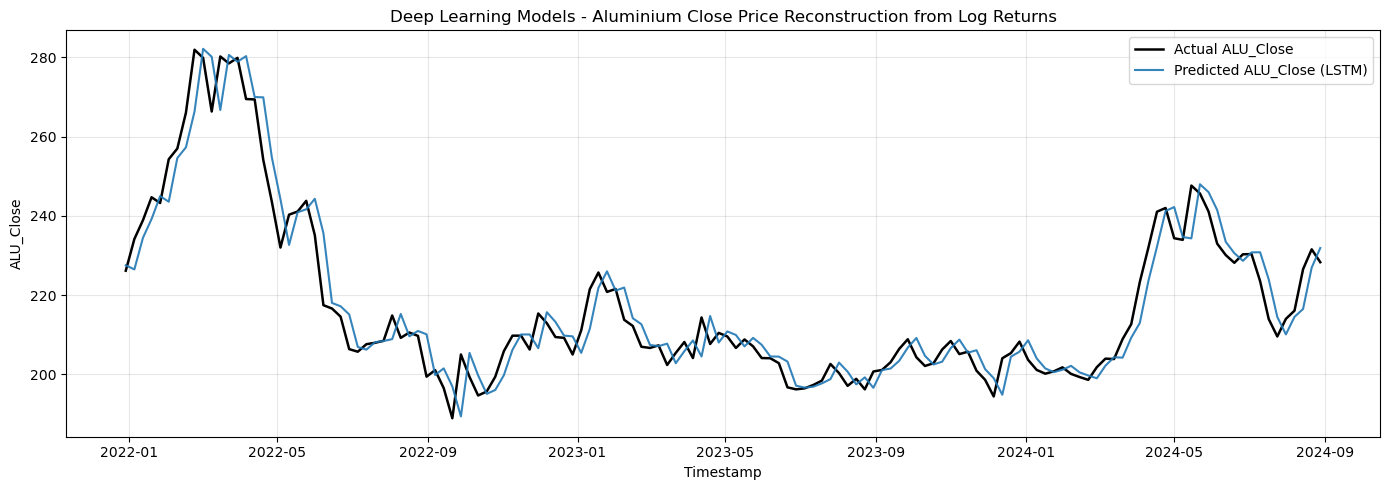

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

price_df = feature_df[["ALU_Close"]].copy().rename(columns={"ALU_Close": "actual_close"})
price_df["prev_close"] = price_df["actual_close"].shift(1)

price_predictions_df = predictions_df.merge(price_df, left_on="timestamp", right_index=True, how="left")
price_predictions_df = price_predictions_df.dropna(subset=["prev_close", "actual_close"]).copy()
price_predictions_df["true_close_from_returns"] = price_predictions_df["prev_close"] * np.exp(price_predictions_df["y_true"])
price_predictions_df["pred_close"] = price_predictions_df["prev_close"] * np.exp(price_predictions_df["y_pred"])

display(price_predictions_df.head())

best_model_name = results_df.iloc[0]["Model"]
best_model_price_df = price_predictions_df[price_predictions_df["model"] == best_model_name].sort_values("timestamp")

plt.figure(figsize=(14, 5))
plt.plot(best_model_price_df["timestamp"], best_model_price_df["actual_close"], label="Actual ALU_Close", color="black", linewidth=1.8)
plt.plot(best_model_price_df["timestamp"], best_model_price_df["pred_close"], label=f"Predicted ALU_Close ({best_model_name})", alpha=0.9)
plt.title("Deep Learning Models - Aluminium Close Price Reconstruction from Log Returns")
plt.xlabel("Timestamp")
plt.ylabel("ALU_Close")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()

price_plot_path = RESULTS_DIR / "dl_models_test_price_predictions.png"
plt.savefig(price_plot_path, dpi=150, bbox_inches="tight")
print(f"Saved price plot to: {price_plot_path}")
plt.show()

,timestamp,fold_id,step_in_fold,model,actual_return,predicted_return,actual_close,predicted_close
0,2021-12-29,1,1,LSTM,-0.004632,0.002009,226.15,227.657013
1,2022-01-05,1,2,LSTM,0.034763,0.001946,234.15,228.100392
2,2022-01-12,1,3,LSTM,0.020083,0.001834,238.90,228.519132
3,2022-01-19,1,4,LSTM,0.023988,0.001734,244.70,228.915696
4,2022-01-26,1,5,LSTM,-0.005943,0.001660,243.25,229.296018


Walk-forward return metrics - MAE: 0.019629, RMSE: 0.025770, R2: -0.002914, DA: 0.485714
Saved walk-forward predictions to: C:\Users\Acer\Desktop\OTH\Master\FPP\fpp\results\torch_deep_models_1h\aluminium_log_ret\dl_models_walk_forward_predictions.csv
Saved walk-forward plot to: C:\Users\Acer\Desktop\OTH\Master\FPP\fpp\results\torch_deep_models_1h\aluminium_log_ret\dl_models_walk_forward_price_plot.png


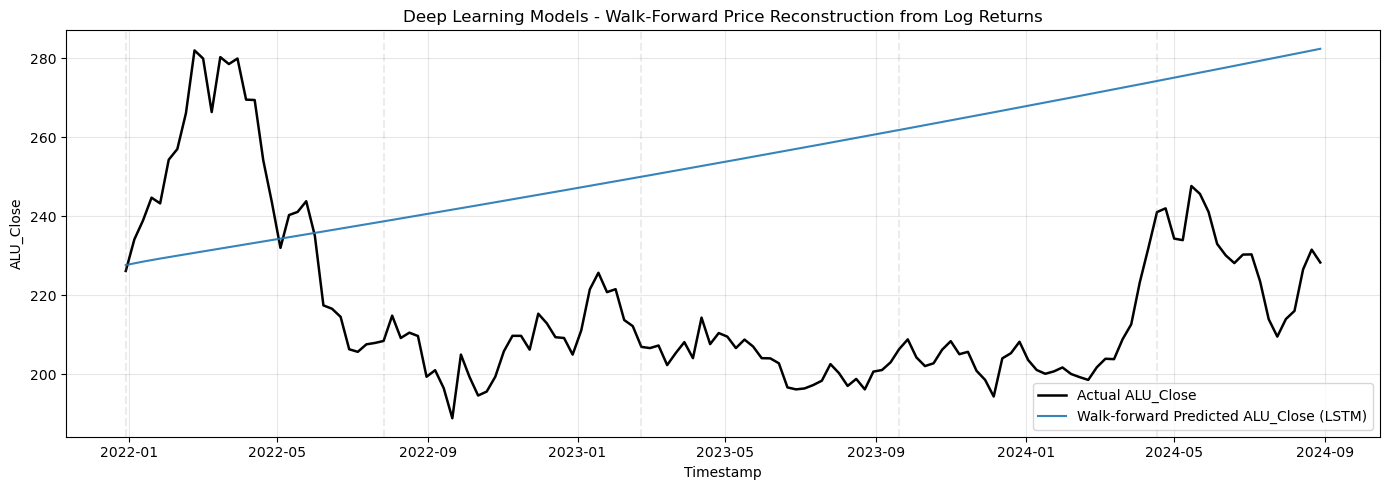

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

WF_MODEL_NAME = best_model_name
WF_BLOCK_SIZE = 30

if isinstance(trained_models, dict) and WF_MODEL_NAME in trained_models:
    wf_model = trained_models[WF_MODEL_NAME].to(device)
else:
    raise KeyError(f"Model '{WF_MODEL_NAME}' is not available in trained_models")
wf_model.eval()

wf_test_index = base_df.index[base_df[MODE_COL] == "Test"]
history_index = base_df.index[base_df[MODE_COL] != "Test"]

scaled_target_values = target_scaler.transform(base_df[TARGET_COL].to_numpy(dtype=np.float32).reshape(-1, 1)).reshape(-1).astype(np.float32)
scaled_covariate_values = covariate_scaler.transform(base_df[COVARIATE_COLUMNS].to_numpy(dtype=np.float32)).astype(np.float32)
scaled_covariate_df = pd.DataFrame(scaled_covariate_values, index=base_df.index, columns=COVARIATE_COLUMNS)

history_mask = base_df[MODE_COL].to_numpy() != "Test"
context_matrix = np.column_stack([scaled_target_values[history_mask], scaled_covariate_values[history_mask]]).astype(np.float32)
current_actual_close = float(base_df.loc[history_index[-1], "ALU_Close"])
current_pred_close = current_actual_close

wf_rows = []
for fold_id, fold_start in enumerate(range(0, len(wf_test_index), WF_BLOCK_SIZE), start=1):
    fold_timestamps = wf_test_index[fold_start:fold_start + WF_BLOCK_SIZE]
    if len(fold_timestamps) == 0:
        continue

    for step_in_fold, timestamp in enumerate(fold_timestamps, start=1):
        model_input = torch.tensor(context_matrix[-LOOKBACK_WINDOW:], dtype=torch.float32).unsqueeze(0).to(device)
        with torch.no_grad():
            scaled_prediction = float(wf_model(model_input).cpu().item())

        predicted_return = float(target_scaler.inverse_transform([[scaled_prediction]])[0, 0])
        actual_return = float(base_df.loc[timestamp, TARGET_COL])

        current_actual_close *= float(np.exp(actual_return))
        current_pred_close *= float(np.exp(predicted_return))

        actual_cov_row = scaled_covariate_df.loc[timestamp].to_numpy(dtype=np.float32)
        new_context_row = np.concatenate(([scaled_prediction], actual_cov_row)).astype(np.float32)
        context_matrix = np.vstack([context_matrix, new_context_row])

        wf_rows.append({
            "timestamp": timestamp,
            "fold_id": fold_id,
            "step_in_fold": step_in_fold,
            "model": WF_MODEL_NAME,
            "actual_return": actual_return,
            "predicted_return": predicted_return,
            "actual_close": current_actual_close,
            "predicted_close": current_pred_close,
        })

wf_predictions_df = pd.DataFrame(wf_rows).sort_values("timestamp").reset_index(drop=True)
display(wf_predictions_df.head())

wf_metrics = evaluate(
    wf_predictions_df.rename(columns={"actual_return": "target", "predicted_return": "pred"}),
    target_col="target",
    y_pred_col="pred",
    do_calculate_directed_accuracy=True,
)
print(
    f"Walk-forward return metrics - MAE: {wf_metrics.mae:.6f}, RMSE: {wf_metrics.rmse:.6f}, R2: {wf_metrics.r2:.6f}, DA: {wf_metrics.directed_accuracy:.6f}"
)

wf_csv_path = RESULTS_DIR / "dl_models_walk_forward_predictions.csv"
wf_predictions_df.to_csv(wf_csv_path, index=False)
print(f"Saved walk-forward predictions to: {wf_csv_path}")

plt.figure(figsize=(14, 5))
plt.plot(wf_predictions_df["timestamp"], wf_predictions_df["actual_close"], label="Actual ALU_Close", color="black", linewidth=1.8)
plt.plot(wf_predictions_df["timestamp"], wf_predictions_df["predicted_close"], label=f"Walk-forward Predicted ALU_Close ({WF_MODEL_NAME})", alpha=0.9)
for _, fold_start in wf_predictions_df.groupby("fold_id")["timestamp"].min().items():
    plt.axvline(fold_start, color="grey", linestyle="--", alpha=0.15)
plt.title("Deep Learning Models - Walk-Forward Price Reconstruction from Log Returns")
plt.xlabel("Timestamp")
plt.ylabel("ALU_Close")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()

wf_plot_path = RESULTS_DIR / "dl_models_walk_forward_price_plot.png"
plt.savefig(wf_plot_path, dpi=150, bbox_inches="tight")
print(f"Saved walk-forward plot to: {wf_plot_path}")
plt.show()